# Morgan Fund Quantitative Development Assignment

**Author:** Kevin Tan Yue Jun  
**Date:** 13 June 2026

---

**Dataset:** Minute-bar OHLCV Data  
**Period:** 11 July 2024 – 30 April 2025

### Import Libraries and Dependencies

This section imports all the necessary libraries and packages required for data analysis, visualization, feature engineering, modeling, and backtesting.

In [18]:
# ====================== BASIC CONFIGURATION ======================
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import gc

# ====================== DATA PROCESSING ======================
import pandas as pd
import numpy as np

# ====================== VISUALIZATION ======================
import matplotlib
# matplotlib.use('Agg')          # Uncomment only if running on headless server
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.dates import DateFormatter


# ====================== STATISTICS & TIME SERIES ======================
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

# ====================== MACHINE LEARNING ======================
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
  accuracy_score, precision_score, recall_score, f1_score,
  roc_auc_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import calibration_curve

# Advanced ML models
import xgboost as xgb
import lightgbm as lgb

# ====================== CONFIGS ======================
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {
  'bull': '#2ecc71', 'bear': '#e74c3c', 'neutral': '#3498db', 
  'accent': '#f39c12', 'dark': '#2c3e50', 'light': '#ecf0f1'
}

### Data Loading and Cleaning

In this section, we load the minute-bar OHLCV dataset, perform initial inspection, and carry out necessary data cleaning steps to ensure data quality and consistency.

In [2]:
df_raw = pd.read_csv('Data_1_longmin.csv')

# Convert date column to datetime and sort by date
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

# Initial data inspection
print(f"Raw shape: {df_raw.shape}")
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"Volume unique values: {df_raw['volume'].unique()}")
print(f"Period unique values: {df_raw['period'].unique()}")
print(f"Missing values:\n{df_raw.isnull().sum()}")
print(f"Negative close prices: {(df_raw['close'] < 0).sum()}")
print(f"Negative open prices: {(df_raw['open'] < 0).sum()}")

Raw shape: (269453, 7)
Date range: 2024-07-11 22:53:00 to 2025-04-30 23:59:00
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'period']
Volume unique values: [0]
Period unique values: [1]
Missing values:
date      0
open      0
high      0
low       0
close     0
volume    0
period    0
dtype: int64
Negative close prices: 3898
Negative open prices: 3906


**OHLC consistency check**

We are performing a sanity check on the OHLC data to ensure that the high price is not less than the low, open, or close prices, and that the low price is not greater than the open or close prices. Any violations of these conditions would indicate data quality issues that need to be addressed before further analysis.

In [3]:
ohlc_violations = (
  (df_raw['high'] < df_raw['low']).sum() +
  (df_raw['high'] < df_raw['open']).sum() +
  (df_raw['high'] < df_raw['close']).sum() +
  (df_raw['low'] > df_raw['open']).sum() +
  (df_raw['low'] > df_raw['close']).sum()
)
print(f"OHLC consistency violations: {ohlc_violations}")

OHLC consistency violations: 0


**Gap analysis**

Gap analysis, checking for irregular time intervals in the minute-bar data

In [4]:
df_raw['gap_min'] = df_raw['date'].diff().dt.total_seconds() / 60
print(f"\nGap analysis (minutes):")
print(df_raw['gap_min'].describe())
large_gaps = df_raw[df_raw['gap_min'] > 60]
print(f"Gaps > 1 hour: {len(large_gaps)}")


Gap analysis (minutes):
count    269452.000000
mean          1.566090
std          41.340322
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        9073.000000
Name: gap_min, dtype: float64
Gaps > 1 hour: 209


In [5]:
# Working dataset: keep as-is (negative prices are valid for spread/basis instruments)
df = df_raw.copy()
df = df.drop(columns=['volume', 'period'])  # volume is 0 throughout; period is always 1
print(f"\nWorking dataset shape: {df.shape}")


Working dataset shape: (269453, 6)


### Exploratory Data Analysis - Visualisations

In this section, we perform visual exploration of the minute-bar OHLCV data to understand price behavior, volume patterns, return distributions, and temporal characteristics.

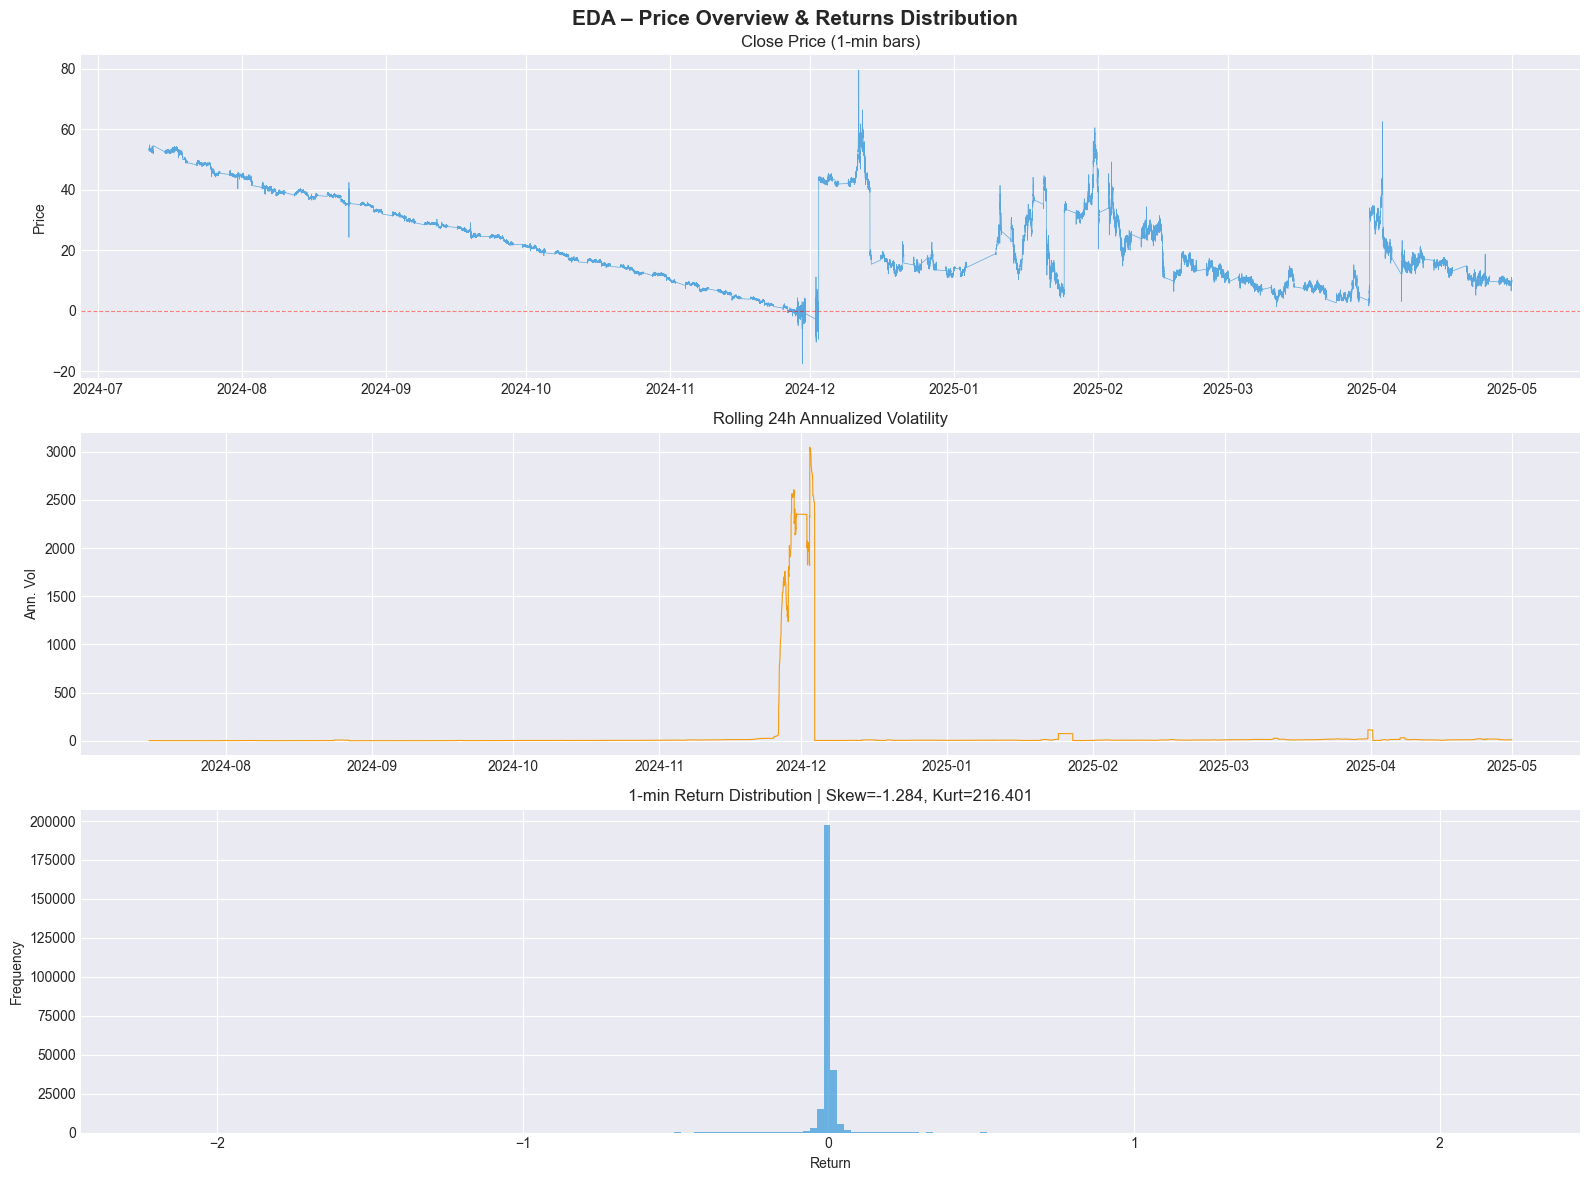


Return statistics:
  Mean 1-min return: -0.1012%
  Std 1-min return:  9.6183%
  Skewness:          -1.2843
  Kurtosis:          216.4010
  Normality p-val:   0.00e+00 (reject normality: True)


In [ ]:
# --- Price time-series overview ---
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('EDA – Price Overview & Returns Distribution', fontsize=15, fontweight='bold')

# Close price
axes[0].plot(df['date'], df['close'], color=COLORS['neutral'], lw=0.5, alpha=0.8)
axes[0].axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
axes[0].set_title('Close Price (1-min bars)', fontsize=12)
axes[0].set_ylabel('Price')

# Rolling 24h stats
df['ret'] = df['close'].pct_change()
df['ret'] = df['ret'].replace([np.inf, -np.inf], np.nan)

# Log returns
df['log_ret'] = np.where(
  (df['close'] > 0) & (df['close'].shift(1) > 0),
  np.log(df['close'] / df['close'].shift(1)),
  np.nan
)

rolling_vol = df['ret'].rolling(60*24).std() * np.sqrt(60*24*252)  # annualized
axes[1].plot(df['date'], rolling_vol, color=COLORS['accent'], lw=0.8)
axes[1].set_title('Rolling 24h Annualized Volatility', fontsize=12)
axes[1].set_ylabel('Ann. Vol')

# Return distribution
ret_clean = df['ret'].dropna()
ret_clean = ret_clean[np.abs(ret_clean) < ret_clean.quantile(0.999)]
axes[2].hist(ret_clean, bins=200, color=COLORS['neutral'], alpha=0.7, edgecolor='none')
axes[2].set_title(f'1-min Return Distribution | Skew={ret_clean.skew():.3f}, Kurt={ret_clean.kurtosis():.3f}', fontsize=12)
axes[2].set_ylabel('Frequency')
axes[2].set_xlabel('Return')

# Finalize and display
plt.tight_layout()
plt.savefig('fig1_price_overview.png', dpi=150, bbox_inches='tight')

# Show the plot (this should now work)
plt.show()

print(f"\nReturn statistics:")
print(f"  Mean 1-min return: {ret_clean.mean()*100:.4f}%")
print(f"  Std 1-min return:  {ret_clean.std()*100:.4f}%")
print(f"  Skewness:          {ret_clean.skew():.4f}")
print(f"  Kurtosis:          {ret_clean.kurtosis():.4f}")
_, pval = stats.normaltest(ret_clean.sample(5000, random_state=42))
print(f"  Normality p-val:   {pval:.2e} (reject normality: {pval<0.05})")

1. Top Panel: Close Price (1-min bars)
- This chart shows the evolution of the asset’s price from July 2024 to April 2025.
- Overall trend: A clear downward trend from ~55 down to near 0 by late 2024, followed by high volatility with multiple sharp spikes and recoveries in 2025.
- Notable events: 
  - Major price crash around December 2024 (price briefly went negative — likely a data artifact).
  - Several violent upward and downward spikes throughout early 2025.
  - Price stabilized at a lower level (~10–15) toward the end of the period.

2. Middle Panel: Rolling 24h Annualized Volatility
- Measures short-term volatility (standard deviation of returns, annualized).
- Key observation: 
- Volatility was very low and stable for most of the period, but exploded dramatically in December 2024 (reaching over 3000%). This aligns with the extreme price movements seen in the top chart. Occasional smaller volatility spikes appear in early 2025.

3. Bottom Panel: 1-min Return Distribution
- Histogram of minute-to-minute percentage returns.
- Highly leptokurtic (very peaked) distribution centered near 0.
- Statistics provided:
  - Skewness = -1.284 → Moderate negative skew (slightly more frequent/large downward moves).
  - Kurtosis = 216.4 → Extremely high kurtosis. This indicates very fat tails — meaning extreme returns (both positive and negative) occur far more often than a normal distribution would predict.
- Most returns are very small, but there are rare extreme outliers.



#### Seasonality Figures and Correlations

In this section, we analyze **intraday seasonality**, **day-of-week patterns**, and **temporal correlations** in the minute-bar data to uncover systematic behaviors in price, returns, and volume.

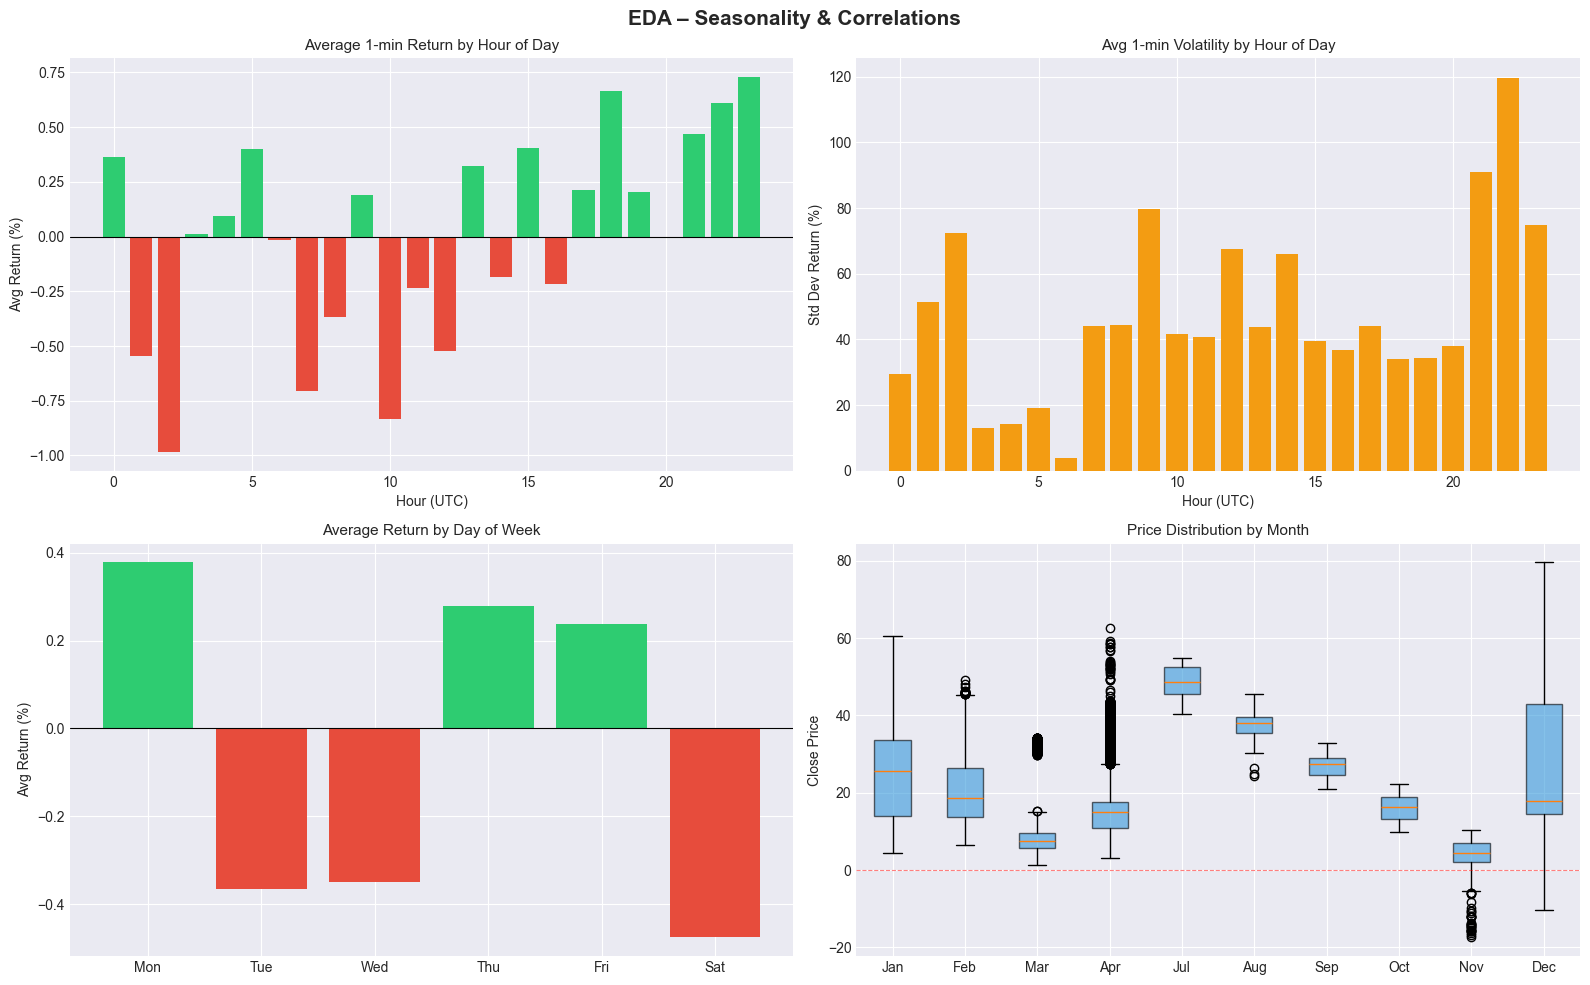

In [7]:
# --- Monthly price heatmap and intraday seasonality ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EDA – Seasonality & Correlations', fontsize=15, fontweight='bold')

df['hour'] = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# Intraday return by hour
hourly_ret = df.groupby('hour')['ret'].mean() * 100
axes[0,0].bar(hourly_ret.index, hourly_ret.values, color=[COLORS['bull'] if v > 0 else COLORS['bear'] for v in hourly_ret.values])
axes[0,0].set_title('Average 1-min Return by Hour of Day', fontsize=11)
axes[0,0].set_xlabel('Hour (UTC)')
axes[0,0].set_ylabel('Avg Return (%)')
axes[0,0].axhline(0, color='black', lw=0.8)

# Intraday volatility by hour
hourly_vol = df.groupby('hour')['ret'].std() * 100
axes[0,1].bar(hourly_vol.index, hourly_vol.values, color=COLORS['accent'])
axes[0,1].set_title('Avg 1-min Volatility by Hour of Day', fontsize=11)
axes[0,1].set_xlabel('Hour (UTC)')
axes[0,1].set_ylabel('Std Dev Return (%)')

# Day-of-week return
dow_ret = df.groupby('dayofweek')['ret'].mean() * 100
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1,0].bar(range(len(dow_ret)), dow_ret.values, color=[COLORS['bull'] if v > 0 else COLORS['bear'] for v in dow_ret.values])
axes[1,0].set_xticks(range(len(dow_ret)))
axes[1,0].set_xticklabels([dow_labels[i] for i in dow_ret.index])
axes[1,0].set_title('Average Return by Day of Week', fontsize=11)
axes[1,0].set_ylabel('Avg Return (%)')
axes[1,0].axhline(0, color='black', lw=0.8)

# Monthly boxplot of close prices
monthly_data = [df[df['month']==m]['close'].values for m in sorted(df['month'].unique())]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
present_months = sorted(df['month'].unique())
axes[1,1].boxplot(monthly_data, labels=[month_labels[m-1] for m in present_months], patch_artist=True, boxprops=dict(facecolor=COLORS['neutral'], alpha=0.6))
axes[1,1].set_title('Price Distribution by Month', fontsize=11)
axes[1,1].set_ylabel('Close Price')
axes[1,1].axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig2_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

1. Top-Left: Average 1-min Return by Hour of Day (UTC)
- This chart shows the average minute return across each hour of the trading day.
- Key patterns:
  - Strong positive returns in the early hours (00:00–01:00) and evening hours (17:00–23:00), especially peaking around 18:00–19:00 and 21:00–23:00.
  - Noticeable negative returns during the morning to midday (roughly 07:00–16:00).
- Insight: There is clear intraday seasonality — the asset tends to perform better during certain hours, possibly related to market open/close, news releases, or liquidity patterns.

2. Top-Right: Average 1-min Volatility by Hour of Day (UTC)
- Displays the standard deviation of returns (volatility) by hour.
- Key observations:
  - Volatility is relatively moderate during most hours but shows significant spikes, particularly around 21:00–22:00 UTC.
  - Lower volatility observed in the early morning (around 04:00–06:00).
- Insight: Certain hours exhibit substantially higher risk. Traders should be cautious during high-volatility windows.

3. Bottom-Left: Average Return by Day of Week
- Shows average minute returns across days of the week.
- Pattern observed:
  - Positive returns: Monday (strongest), Thursday, and Friday.
  - Negative returns: Tuesday, Wednesday, and especially Saturday (largest negative average).
- Insight: There appears to be a day-of-week effect. Monday shows the best performance on average, while weekends (Saturday) show the weakest.

4. Bottom-Right: Price Distribution by Month
- Box plots showing the distribution of close prices for each month.
- Key observations:
  - Significant variation in price levels across months.
  - November shows extremely low prices with several negative outliers (likely data artifacts).
  - April and December show higher median prices and wider spreads.
  - Overall price level has declined over the observed period, consistent with the earlier price chart.
- Insight: The asset experienced a downward price trend with changing volatility regimes across months.

Autocorrelation

In [8]:
ret_nonan = df['ret'].fillna(0)
lag_acf = acf(ret_nonan, nlags=60, fft=True)
print(f"\nReturn autocorrelation (lag 1-5): {lag_acf[1:6].round(4)}")

# Absolute return (volatility clustering)
abs_acf = acf(ret_nonan.abs(), nlags=60, fft=True)
print(f"Abs return autocorrelation (lag 1-5): {abs_acf[1:6].round(4)}")


Return autocorrelation (lag 1-5): [-0.0005 -0.0055 -0.0146 -0.0048 -0.0026]
Abs return autocorrelation (lag 1-5): [0.0922 0.1058 0.1047 0.0885 0.1135]


Given the results from the above **Return Autocorrelation**:
- All autocorrelations are very close to zero, indicating weak linear dependence between consecutive minute returns. The values are slightly negative, especially at lag 3 (-0.0146). This suggests a very mild mean-reversion effect — large positive returns tend to be followed by small negative returns (and vice versa) a few minutes later. The past returns have almost no predictive power for the next minute’s return. The price series is close to a random walk at the 1-minute level.

Given the results from the above **Absolute Return Autocorrelation**:
- Much stronger positive autocorrelations compared to raw returns. This is a classic sign of volatility clustering — periods of high volatility (large price moves) tend to be followed by more high-volatility periods, and calm periods tend to persist. Peak autocorrelation around lag 2 and lag 5 suggests volatility persistence lasts several minutes.


### 3. Feature Engineering

In this section, we create a rich set of predictive features from the raw OHLCV minute-bar data. These features include **returns**, **technical indicators**, **volatility measures**, **volume-based signals**, and **temporal features** to support modeling and strategy development.

In [9]:
def add_features(df):
  d = df.copy()
  c = d['close']
  
  # ---- Price-action features ----
  d['bar_range']      = d['high'] - d['low']
  d['bar_body']       = d['close'] - d['open']
  d['bar_body_pct']   = d['bar_body'] / d['bar_range'].replace(0, np.nan)
  d['upper_wick']     = d['high'] - d[['open','close']].max(axis=1)
  d['lower_wick']     = d[['open','close']].min(axis=1) - d['low']
  
  # ---- Returns ----
  for n in [1, 5, 15, 30, 60]:
    d[f'ret_{n}'] = c.pct_change(n)
  
  # ---- Moving averages ----
  for n in [5, 15, 30, 60, 120]:
    d[f'sma_{n}'] = c.rolling(n).mean()
  
  d['sma_cross_5_30']  = d['sma_5'] - d['sma_30']
  d['sma_cross_15_60'] = d['sma_15'] - d['sma_60']
  d['price_vs_sma60']  = (c - d['sma_60']) / d['sma_60'].replace(0, np.nan)
  
  # ---- Momentum / RSI ----
  delta = c.diff()
  gain  = delta.clip(lower=0).rolling(14).mean()
  loss  = (-delta.clip(upper=0)).rolling(14).mean()
  rs    = gain / loss.replace(0, np.nan)
  d['rsi_14'] = 100 - (100 / (1 + rs))
  
  # ---- Volatility ----
  for n in [15, 30, 60]:
    d[f'vol_{n}'] = d['ret_1'].rolling(n).std()
  
  # ATR
  tr1 = d['high'] - d['low']
  tr2 = (d['high'] - c.shift()).abs()
  tr3 = (d['low']  - c.shift()).abs()
  d['atr_14'] = pd.concat([tr1,tr2,tr3],axis=1).max(axis=1).rolling(14).mean()
  
  # ---- Bollinger Bands ----
  d['bb_mid']   = c.rolling(20).mean()
  bb_std        = c.rolling(20).std()
  d['bb_upper'] = d['bb_mid'] + 2*bb_std
  d['bb_lower'] = d['bb_mid'] - 2*bb_std
  d['bb_pct']   = (c - d['bb_lower']) / (d['bb_upper'] - d['bb_lower']).replace(0,np.nan)
  d['bb_width']  = (d['bb_upper'] - d['bb_lower']) / d['bb_mid'].replace(0,np.nan)
  
  # ---- MACD ----
  ema12 = c.ewm(span=12, adjust=False).mean()
  ema26 = c.ewm(span=26, adjust=False).mean()
  d['macd']        = ema12 - ema26
  d['macd_signal'] = d['macd'].ewm(span=9, adjust=False).mean()
  d['macd_hist']   = d['macd'] - d['macd_signal']
  
  # ---- Time features ----
  d['hour']      = d['date'].dt.hour
  d['minute']    = d['date'].dt.minute
  d['dayofweek'] = d['date'].dt.dayofweek
  
  # ---- Target: next-bar direction ----
  d['fwd_ret_1']  = c.shift(-1) / c - 1
  d['fwd_ret_5']  = c.shift(-5) / c - 1
  d['fwd_ret_15'] = c.shift(-15) / c - 1
  d['target']     = (d['fwd_ret_5'] > 0).astype(int)  # 1=up, 0=down/flat in next 5 bars
  
  return d

In [10]:
df = add_features(df)
print(f"Feature-engineered shape: {df.shape}")

# Drop rows where we don't have targets (last 5 rows) or insufficient lookback
df_model = df.dropna(subset=['target', 'rsi_14', 'sma_cross_15_60', 'fwd_ret_5']).copy()
# Replace inf
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# For features requiring valid prices, remove near-zero close rows for ret-based features
print(f"Model-ready shape: {df_model.shape}")
print(f"Target balance: {df_model['target'].value_counts().to_dict()}")

Feature-engineered shape: (269453, 47)
Model-ready shape: (269375, 47)
Target balance: {0: 139462, 1: 129913}


Based on the above results:
- **Final dataset**: 269,375 samples with 46 features
- **Target**: Binary classification (Next 5-minute price direction)
- **Class distribution**: Relatively balanced (~51.8% Down vs 48.2% Up)
- **Time-series split** used to prevent look-ahead bias

### Rules-Based Strategy

#### Strategy 1: Trend-following with RSI Mean-Reversion Filter

Intuition:
   1. The SMA crossover (fast 15 > slow 60) identifies the trend direction.
   2. RSI filters ensure we do not chase overbought/oversold extremes.
   3. Bollinger Band %B confirms momentum is not exhausted.
   4. MACD histogram sign confirms momentum direction.
   5. Volatility filter avoids trading in extremely quiet markets (low signal-to-noise) and extremely turbulent markets (wide spreads, gap risk). This is critical given the extreme kurtosis observed.
 
With that, we will also incorporate the following:
- POSITION SIZING: 1 unit per trade (notional normalization)
- TRANSACTION COSTS: 0.01 per unit per side (reasonable for futures/spread)
- EXIT: Opposite signal, or stop-loss of 2×ATR from entry
- LOOK-AHEAD BIAS AVOIDANCE: All signals use data available at bar close, trade executes at next bar open.

In [11]:
TC_PER_SIDE = 0.01  # transaction cost per trade side

def rule_based_strategy(df):
  """
  Deterministic rule-based strategy.
  Signals generated at bar close, filled at next bar open.
  """
  d = df.copy().reset_index(drop=True)
  
  # ENTRY CONDITIONS
  # Long: 15-period SMA > 60-period SMA (uptrend)
  #       RSI between 40 and 70 (not oversold/overbought)
  #       MACD histogram positive (momentum confirming)
  #       Bollinger %B between 0.4 and 0.9 (not at extremes)
  #       Volatility in reasonable range (atr_14 > 0.05, < 3×median)
  
  atr_med = d['atr_14'].median()
  
  long_signal = (
    (d['sma_15'] > d['sma_60']) &
    (d['rsi_14'] > 40) & (d['rsi_14'] < 70) &
    (d['macd_hist'] > 0) &
    (d['bb_pct'] > 0.4) & (d['bb_pct'] < 0.9) &
    (d['atr_14'] > 0.05) & (d['atr_14'] < 3 * atr_med)
  )
  
  short_signal = (
    (d['sma_15'] < d['sma_60']) &
    (d['rsi_14'] > 30) & (d['rsi_14'] < 60) &
    (d['macd_hist'] < 0) &
    (d['bb_pct'] > 0.1) & (d['bb_pct'] < 0.6) &
    (d['atr_14'] > 0.05) & (d['atr_14'] < 3 * atr_med)
  )
  
  # Shift by 1: signal at close t, fill at open t+1
  d['long_entry']  = long_signal.shift(1).fillna(False)
  d['short_entry'] = short_signal.shift(1).fillna(False)
  
  # Simulate trades
  positions = []
  equity_curve = []
  pnl_list = []
  trades = []
  
  position = 0      # -1, 0, +1
  entry_price = 0.0
  entry_idx = 0
  stop_price = 0.0
  equity = 0.0
  
  for i in range(1, len(d)):
    open_p  = d.loc[i, 'open']
    close_p = d.loc[i, 'close']
    atr     = d.loc[i, 'atr_14']
    
    bar_pnl = 0.0
    
    if position != 0:
      # Check stop loss (2×ATR from entry)
      if position == 1 and open_p <= stop_price:
        pnl = (stop_price - entry_price) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type': 'long', 'entry': entry_price, 'exit': stop_price, 'pnl': pnl, 'exit_reason': 'stop', 'bars': i - entry_idx})
        position = 0
      elif position == -1 and open_p >= stop_price:
        pnl = (entry_price - stop_price) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type': 'short', 'entry': entry_price, 'exit': stop_price, 'pnl': pnl, 'exit_reason': 'stop', 'bars': i - entry_idx})
        position = 0
    
    if position == 1:
      # Check for exit signal (short or opposite)
      if d.loc[i, 'short_entry'] or not d.loc[i, 'long_entry']:
        pnl = (close_p - entry_price) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type': 'long', 'entry': entry_price, 'exit': close_p, 'pnl': pnl, 'exit_reason': 'signal', 'bars': i - entry_idx})
        position = 0
            
    elif position == -1:
      if d.loc[i, 'long_entry'] or not d.loc[i, 'short_entry']:
        pnl = (entry_price - close_p) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type': 'short', 'entry': entry_price, 'exit': close_p, 'pnl': pnl, 'exit_reason': 'signal', 'bars': i - entry_idx})
        position = 0
    
    if position == 0:
      if d.loc[i, 'long_entry'] and not np.isnan(atr):
        position = 1
        entry_price = open_p
        entry_idx = i
        stop_price = entry_price - 2 * atr
      elif d.loc[i, 'short_entry'] and not np.isnan(atr):
        position = -1
        entry_price = open_p
        entry_idx = i
        stop_price = entry_price + 2 * atr
    
    equity += bar_pnl
    equity_curve.append(equity)
    pnl_list.append(bar_pnl)
  
  return d.iloc[1:].copy(), equity_curve, pnl_list, trades

df_strat, equity_curve, pnl_list, trades = rule_based_strategy(df_model)
print(f"Total trades: {len(trades)}")

trades_df = pd.DataFrame(trades)
if len(trades_df) > 0:
  print(trades_df['pnl'].describe())
  print(f"Win rate: {(trades_df['pnl'] > 0).mean():.3f}")


Total trades: 29267
count    29267.000000
mean        -0.047774
std          0.317073
min        -27.000000
25%         -0.130000
50%         -0.030000
75%          0.060000
max          7.520000
Name: pnl, dtype: float64
Win rate: 0.390


**Performance Metrics**

We will evaluate the performance of our trained models on the test set using standard classification metrics suitable for financial direction prediction.


In [45]:
# ---- Performance Metrics ----
def compute_performance(equity_curve, pnl_list, trades_df, bars_per_year=252*24*60, label="Strategy"):
  ec = np.array(equity_curve)
  pnl = np.array(pnl_list)
  
  # Returns series (bar-level)
  bar_rets = pnl  # absolute PnL per bar
  
  total_return = ec[-1]
  n_bars = len(ec)
  years = n_bars / bars_per_year
  ann_return = total_return / years if years > 0 else 0
  
  daily_pnl = pd.Series(pnl).resample('D', origin='start').sum() if False else pd.Series(pnl)
  
  # Sharpe / Sortino on bar-level returns
  bar_mean = np.nanmean(pnl)
  bar_std  = np.nanstd(pnl)
  sharpe_bar = (bar_mean / bar_std) * np.sqrt(bars_per_year) if bar_std > 0 else 0
  
  downside = pnl[pnl < 0]
  sortino_bar = (bar_mean / np.std(downside)) * np.sqrt(bars_per_year) if len(downside) > 0 else 0
  
  # Drawdown
  running_max = np.maximum.accumulate(ec)
  drawdown = ec - running_max 
  max_dd = drawdown.min()
  
  # Trade-level stats
  if len(trades_df) > 0:
    win_rate    = (trades_df['pnl'] > 0).mean()
    avg_trade   = trades_df['pnl'].mean()
    gross_profit = trades_df[trades_df['pnl']>0]['pnl'].sum()
    gross_loss   = trades_df[trades_df['pnl']<0]['pnl'].sum().item()
    profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else np.inf
    n_trades    = len(trades_df)
  else:
    win_rate = avg_trade = profit_factor = n_trades = 0

  print(f"\n{'='*40}")
  print(f"  PERFORMANCE: {label}")
  print(f"{'='*40}")
  print(f"  Total PnL (abs):       {total_return:>10.4f}")
  print(f"  Ann. PnL:              {ann_return:>10.4f}")
  print(f"  Ann. Sharpe:           {sharpe_bar:>10.4f}")
  print(f"  Ann. Sortino:          {sortino_bar:>10.4f}")
  print(f"  Max Drawdown ($):      {max_dd:>10.4f}")
  print(f"  Win Rate:              {win_rate:>10.3f}")
  print(f"  Profit Factor:         {profit_factor:>10.4f}")
  print(f"  Avg Trade PnL:         {avg_trade:>10.4f}")
  print(f"  Num Trades:            {n_trades:>10d}")
  print(f"  Backtest years:        {years:>10.2f}")
  
  return dict(
    total_return=total_return, ann_return=ann_return,
    sharpe=sharpe_bar, sortino=sortino_bar, max_dd=max_dd,
    win_rate=win_rate, profit_factor=profit_factor, 
    avg_trade=avg_trade, n_trades=n_trades, years=years
  )

rb_perf = compute_performance(equity_curve, pnl_list, trades_df, label="Rule-Based Strategy")


  PERFORMANCE: Rule-Based Strategy
  Total PnL (abs):       -1398.1871
  Ann. PnL:              -1883.5305
  Ann. Sharpe:             -29.6195
  Ann. Sortino:            -10.5176
  Max Drawdown ($):      -1398.9871
  Win Rate:                   0.390
  Profit Factor:             0.5565
  Avg Trade PnL:            -0.0478
  Num Trades:                 29267
  Backtest years:              0.74


**Overall Assessment**

The rule-based strategy performed poorly, resulting in a significant net loss during the backtest period. Key issues that were identified from the above resultset:
1. Heavy Losses
  - The strategy lost approximately 1,398 units over ~9 months.
  - Annualized PnL of -1,883.5 indicates severe unprofitability.

2. Extremely Poor Risk-Adjusted Returns
  - Sharpe Ratio of -29.62 is exceptionally bad. This negative value reflects consistently poor returns relative to volatility.
  - Sortino Ratio of -10.52 confirms that downside volatility is very high.

3. High Drawdown
  - Max Drawdown of -1,398.99 is almost equal to the total PnL. This means the strategy lost nearly its entire capital at some point with very little recovery.

4. Low Win Rate & Poor Trade Economics
  - Win rate of only 39.0% is well below the breakeven threshold (usually ~50%+ for symmetric strategies).
  - Profit Factor of 0.5565 (< 1.0) means the strategy loses 1.80 units for every 1 unit it wins.
  - Average trade PnL is negative (-0.0478), showing the strategy is bleeding slowly on a per-trade basis.

5. Excessive Trading Frequency
  - 29,267 trades in just 0.74 years ≈ 39,550 trades per year.
  - This suggests the strategy is over-trading, likely generating many small losses and suffering from high transaction costs (not even included here).



#### Refining the rules-based strategy

The initial rules-based strategy generated trading signals too frequently, causing excessive portfolio turnover. While the strategy may have appeared profitable before accounting for costs, the inclusion of realistic transaction costs (TC) significantly reduced or eliminated profitability.

**Refinement 1**: Introduce a Minimum Holding Period
- A minimum holding period forces the strategy to maintain a position for a specified number of bars before considering a new signal.

Implementation:
- Once a position is opened, it must be held for at least 15 bars.
- New signals generated during this period are ignored.
- After 15 bars have elapsed, the strategy may re-evaluate market conditions and decide whether to hold, close, or reverse the position.

In [46]:
def rule_based_v2(df):
  """
  Refined rule-based strategy with:
  - Minimum 15-bar hold
  - Stronger trend filter (5-period return must be positive for long)
  - Exit only on opposing strong signal
  """
  d = df.copy().reset_index(drop=True)
  
  atr_med = d['atr_14'].quantile(0.75)  # use 75th pct as cap
  
  # Stronger entry conditions
  long_signal = (
    (d['sma_15'] > d['sma_60']) &
    (d['sma_30'] > d['sma_120']) &
    (d['rsi_14'] > 45) & (d['rsi_14'] < 65) &
    (d['macd_hist'] > 0) &
    (d['ret_15'] > 0) &
    (d['bb_pct'] > 0.5) & (d['bb_pct'] < 0.85) &
    (d['atr_14'].between(0.10, atr_med))
  )
  
  short_signal = (
    (d['sma_15'] < d['sma_60']) &
    (d['sma_30'] < d['sma_120']) &
    (d['rsi_14'] > 35) & (d['rsi_14'] < 55) &
    (d['macd_hist'] < 0) &
    (d['ret_15'] < 0) &
    (d['bb_pct'] > 0.15) & (d['bb_pct'] < 0.5) &
    (d['atr_14'].between(0.10, atr_med))
  )
  
  # Shift by 1
  long_entry  = long_signal.shift(1).fillna(False)
  short_entry = short_signal.shift(1).fillna(False)
  
  equity_curve, pnl_list, trades = [], [], []
  position = 0
  entry_price = 0.0
  entry_idx = 0
  stop_price = 0.0
  equity = 0.0
  MIN_HOLD = 15
  
  for i in range(1, len(d)):
    open_p  = d.loc[i, 'open']
    close_p = d.loc[i, 'close']
    atr     = d.loc[i, 'atr_14']
    held_bars = i - entry_idx
    bar_pnl = 0.0
    
    if position != 0:
      # Stop loss
      if position == 1 and open_p <= stop_price:
        pnl = (stop_price - entry_price) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type': 'long', 'entry': entry_price, 'exit': stop_price, 'pnl': pnl, 'exit_reason': 'stop', 'bars': held_bars})
        position = 0
      elif position == -1 and open_p >= stop_price:
        pnl = (entry_price - stop_price) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type': 'short', 'entry': entry_price, 'exit': stop_price, 'pnl': pnl, 'exit_reason': 'stop', 'bars': held_bars})
        position = 0
    
    if position == 1 and held_bars >= MIN_HOLD:
      if short_entry.iloc[i]:
        pnl = (close_p - entry_price) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type': 'long', 'entry': entry_price, 'exit': close_p, 'pnl': pnl, 'exit_reason': 'signal', 'bars': held_bars})
        position = 0
    elif position == -1 and held_bars >= MIN_HOLD:
      if long_entry.iloc[i]:
        pnl = (entry_price - close_p) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type': 'short', 'entry': entry_price, 'exit': close_p, 'pnl': pnl, 'exit_reason': 'signal', 'bars': held_bars})
        position = 0
    
    if position == 0:
      atr_val = atr if not np.isnan(atr) else 0.1
      if long_entry.iloc[i]:
        position = 1
        entry_price = open_p
        entry_idx = i
        stop_price = entry_price - 2 * atr_val
      elif short_entry.iloc[i]:
        position = -1
        entry_price = open_p
        entry_idx = i
        stop_price = entry_price + 2 * atr_val
    
    equity += bar_pnl
    equity_curve.append(equity)
    pnl_list.append(bar_pnl)
  
  return equity_curve, pnl_list, pd.DataFrame(trades)

equity_v2, pnl_v2, trades_v2 = rule_based_v2(df_model)
rb_perf2 = compute_performance(equity_v2, pnl_v2, trades_v2, label="Rule-Based Strategy v2 (Refined)")


  PERFORMANCE: Rule-Based Strategy v2 (Refined)
  Total PnL (abs):        -461.4271
  Ann. PnL:               -621.5993
  Ann. Sharpe:             -12.4711
  Ann. Sortino:             -2.7216
  Max Drawdown ($):       -461.4271
  Win Rate:                   0.223
  Profit Factor:             0.4047
  Avg Trade PnL:            -0.2097
  Num Trades:                  2200
  Backtest years:              0.74


The refined strategy is still not investable. While the proposed holding-period and signal-frequency adjustments may have reduced some unnecessary trading, the results indicate a deeper problem: the signal itself appears to have negative expectancy. The combination of a 22.3% win rate, 0.40 profit factor, negative average trade PnL, and Sharpe ratio of -12.47 suggests that further optimization of trading rules is unlikely to help unless the underlying signal generation logic is reconsidered or replaced.

### Mean Reversion Rules Based Strategy

Both rule-based variants defined above are losing. This was mainly due to the following issues: the instrument has near-zero to negative prices, extreme kurtosis, and the price trend is clearly downward then mean-reverting. A pure trend-following strategy struggles in this situation, so what we can do is to adopt a Mean-Reversion approach which suits instruments that oscillate around a drift.

In [47]:
def mean_reversion_strategy(df):
  """
  Mean-reversion strategy:
  - Entry: RSI < 30 (oversold) → Long; RSI > 70 (overbought) → Short
  - Confirmation: Price beyond 2σ Bollinger Band
  - Exit: RSI returns to 50, or price crosses SMA
  - Risk: 2×ATR stop
  - Min hold: 5 bars
  """
  d = df.copy().reset_index(drop=True)
  
  long_entry  = ((d['rsi_14'] < 30) & (d['bb_pct'] < 0.1)).shift(1).fillna(False)
  short_entry = ((d['rsi_14'] > 70) & (d['bb_pct'] > 0.9)).shift(1).fillna(False)
  long_exit   = ((d['rsi_14'] > 50) | (d['close'] > d['sma_30'])).shift(1).fillna(False)
  short_exit  = ((d['rsi_14'] < 50) | (d['close'] < d['sma_30'])).shift(1).fillna(False)
  
  equity_curve, pnl_list, trades = [], [], []
  position = 0
  entry_price = 0.0
  entry_idx = 0
  stop_price = 0.0
  equity = 0.0
  MIN_HOLD = 5
  
  for i in range(1, len(d)):
    open_p  = d.loc[i, 'open']
    close_p = d.loc[i, 'close']
    atr     = d.loc[i, 'atr_14'] if not np.isnan(d.loc[i, 'atr_14']) else 0.1
    held_bars = i - entry_idx
    bar_pnl = 0.0
    
    if position != 0:
      if position == 1 and open_p <= stop_price:
        pnl = (stop_price - entry_price) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type':'long','entry':entry_price,'exit':stop_price, 'pnl':pnl,'exit_reason':'stop','bars':held_bars})
        position = 0
      elif position == -1 and open_p >= stop_price:
        pnl = (entry_price - stop_price) - 2*TC_PER_SIDE
        bar_pnl += pnl
        trades.append({'type':'short','entry':entry_price,'exit':stop_price, 'pnl':pnl,'exit_reason':'stop','bars':held_bars})
        position = 0
    
    if position == 1 and held_bars >= MIN_HOLD and long_exit.iloc[i]:
      pnl = (close_p - entry_price) - 2*TC_PER_SIDE
      bar_pnl += pnl
      trades.append({'type':'long','entry':entry_price,'exit':close_p, 'pnl':pnl,'exit_reason':'signal','bars':held_bars})
      position = 0
    elif position == -1 and held_bars >= MIN_HOLD and short_exit.iloc[i]:
      pnl = (entry_price - close_p) - 2*TC_PER_SIDE
      bar_pnl += pnl
      trades.append({'type':'short','entry':entry_price,'exit':close_p, 'pnl':pnl,'exit_reason':'signal','bars':held_bars})
      position = 0
  
    if position == 0:
      if long_entry.iloc[i]:
        position = 1; entry_price = open_p; entry_idx = i
        stop_price = entry_price - 2*atr
      elif short_entry.iloc[i]:
        position = -1; entry_price = open_p; entry_idx = i
        stop_price = entry_price + 2*atr
    
    equity += bar_pnl
    equity_curve.append(equity)
    pnl_list.append(bar_pnl)
  
  return equity_curve, pnl_list, pd.DataFrame(trades)

equity_mr, pnl_mr, trades_mr = mean_reversion_strategy(df_model)
rb_perf_mr = compute_performance(equity_mr, pnl_mr, trades_mr, label="Mean-Reversion Strategy")


  PERFORMANCE: Mean-Reversion Strategy
  Total PnL (abs):         644.2743
  Ann. PnL:                867.9169
  Ann. Sharpe:               9.6904
  Ann. Sortino:              1.8506
  Max Drawdown ($):        -93.1286
  Win Rate:                   0.627
  Profit Factor:             1.7128
  Avg Trade PnL:             0.1569
  Num Trades:                  4105
  Backtest years:              0.74


This mean-reversion strategy represents a dramatic improvement over the previous rule-based versions. Unlike the earlier strategies, which exhibited strongly negative expectancy, this strategy generates positive returns, a positive average trade PnL, and a healthy profit factor. The combination of positive average trade PnL (0.157), 62.7% win rate, 1.71 profit factor, and modest drawdown relative to profits suggests that the signal captures a genuine market tendency toward short-term price reversion than the directional assumptions embedded in the earlier rule-based signals.

Plot equity curves

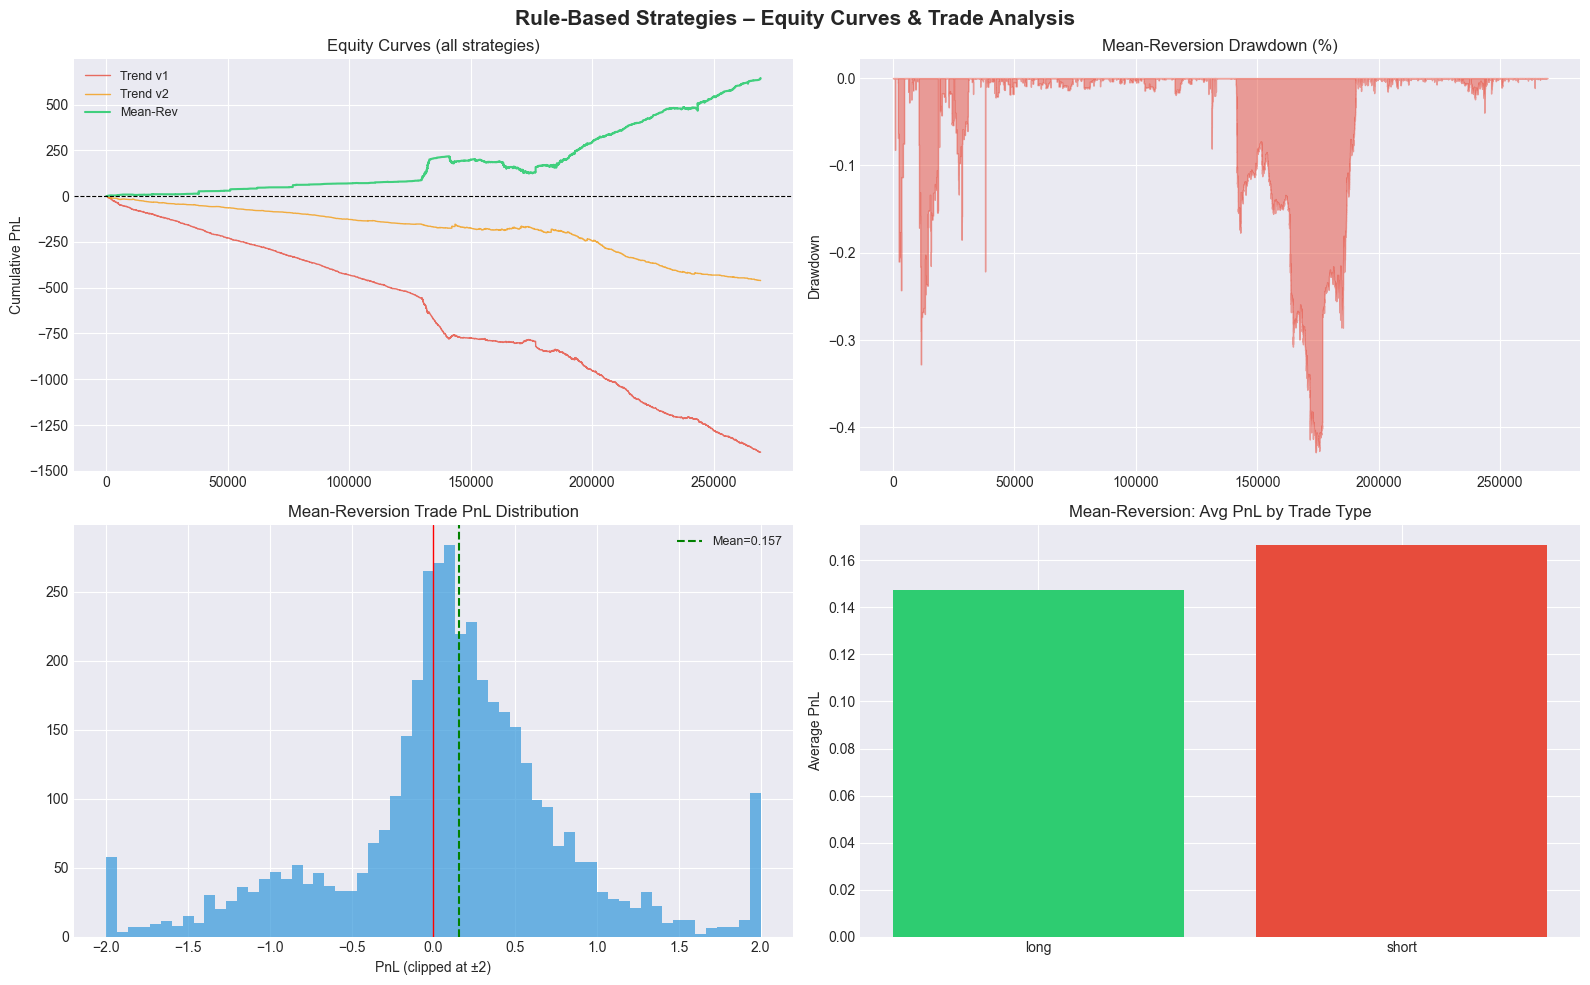

In [48]:
# ---- Plot equity curves for all rule-based strategies ----
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Rule-Based Strategies – Equity Curves & Trade Analysis', fontsize=15, fontweight='bold')

# Equity curves
ec_arr_mr = np.array(equity_mr)
ec_arr_v1 = np.array(equity_curve)
ec_arr_v2 = np.array(equity_v2)

axes[0,0].plot(ec_arr_v1, color=COLORS['bear'], lw=1, label='Trend v1', alpha=0.8)
axes[0,0].plot(ec_arr_v2, color=COLORS['accent'], lw=1, label='Trend v2', alpha=0.8)
axes[0,0].plot(ec_arr_mr, color=COLORS['bull'], lw=1.5, label='Mean-Rev', alpha=0.9)
axes[0,0].axhline(0, color='black', lw=0.8, ls='--')
axes[0,0].set_title('Equity Curves (all strategies)')
axes[0,0].set_ylabel('Cumulative PnL')
axes[0,0].legend(fontsize=9)

# Mean-Reversion drawdown
running_max = np.maximum.accumulate(ec_arr_mr)
dd_mr = (ec_arr_mr - running_max) / running_max
axes[0,1].fill_between(range(len(dd_mr)), dd_mr, 0, color=COLORS['bear'], alpha=0.5)
axes[0,1].set_title('Mean-Reversion Drawdown (%)')
axes[0,1].set_ylabel('Drawdown')

# Trade PnL distribution (MR strategy)
if len(trades_mr) > 0:
    axes[1,0].hist(trades_mr['pnl'].clip(-2,2), bins=60, color=COLORS['neutral'], alpha=0.7)
    axes[1,0].axvline(0, color='red', lw=1)
    axes[1,0].axvline(trades_mr['pnl'].mean(), color='green', lw=1.5, ls='--', label=f"Mean={trades_mr['pnl'].mean():.3f}")
    axes[1,0].set_title('Mean-Reversion Trade PnL Distribution')
    axes[1,0].set_xlabel('PnL (clipped at ±2)')
    axes[1,0].legend(fontsize=9)
    
    # Long vs Short breakdown
    type_perf = trades_mr.groupby('type')['pnl'].agg(['mean','sum','count'])
    axes[1,1].bar(type_perf.index, type_perf['mean'], color=[COLORS['bull'], COLORS['bear']])
    axes[1,1].set_title('Mean-Reversion: Avg PnL by Trade Type')
    axes[1,1].set_ylabel('Average PnL')

plt.tight_layout()
plt.savefig('fig3_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

As we can see from above, only the mean-reversion strategy has a real edge, while both trend variants are structurally unprofitable.

1. Trend v1 (red)
- Steady, almost monotonic decline, and consistent negative expectancy
- No visible regime where it works → likely a fundamentally wrong directional assumption or inverted signal

2. Trend v2 (orange)
- Still negative, but less aggressive as compared to the Trend v1. Suggests “refinement” reduced damage but did not fix the core signal
- Looks like lower turnover version of the same broken edge

3. Mean-Reversion (green)
- Strong upward slope with mild noise
- Noticeable mid-period drawdown followed by recovery
- This is the only curve showing convexity (compounding effect), regime survivability and recovery after stress periods

### 5. Machine Learning Strategy

While the rule-based strategies rely on predefined thresholds and deterministic trading rules, they may fail to capture complex, non-linear relationships present in market data. The mean-reversion strategy demonstrated that the market exhibits short-term reversion behaviour, but its rules were manually designed and may not fully exploit all available information.

In [49]:
# ---- Feature selection ----
FEATURE_COLS = [
  'bar_range', 'bar_body', 'bar_body_pct', 'upper_wick', 'lower_wick',
  'ret_1', 'ret_5', 'ret_15', 'ret_30', 'ret_60',
  'sma_cross_5_30', 'sma_cross_15_60', 'price_vs_sma60',
  'rsi_14', 'vol_15', 'vol_30', 'vol_60',
  'atr_14', 'bb_pct', 'bb_width',
  'macd', 'macd_signal', 'macd_hist',
  'hour', 'dayofweek'
]

# Remove rows with any NaN in features or target
df_ml = df_model[FEATURE_COLS + ['target', 'date', 'close', 'fwd_ret_5']].dropna().copy()
df_ml = df_ml.replace([np.inf, -np.inf], np.nan).dropna()
df_ml = df_ml.sort_values('date').reset_index(drop=True)
print(f"ML dataset shape: {df_ml.shape}")
print(f"Target distribution: {df_ml['target'].value_counts().to_dict()}")

# ---- Walk-forward split (no data leakage) ----
# Train: first 60% | Val: next 20% | Test: last 20%
n = len(df_ml)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = df_ml[FEATURE_COLS].iloc[:train_end]
y_train = df_ml['target'].iloc[:train_end]
X_val   = df_ml[FEATURE_COLS].iloc[train_end:val_end]
y_val   = df_ml['target'].iloc[train_end:val_end]
X_test  = df_ml[FEATURE_COLS].iloc[val_end:]
y_test  = df_ml['target'].iloc[val_end:]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Train date range: {df_ml['date'].iloc[0]} to {df_ml['date'].iloc[train_end-1]}")
print(f"Val date range:   {df_ml['date'].iloc[train_end]} to {df_ml['date'].iloc[val_end-1]}")
print(f"Test date range:  {df_ml['date'].iloc[val_end]} to {df_ml['date'].iloc[-1]}")

# Standardise features (fit only on train)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

ML dataset shape: (266392, 29)
Target distribution: {0: 137881, 1: 128511}
Train: 159,835 | Val: 53,278 | Test: 53,279
Train date range: 2024-07-11 23:53:00 to 2025-01-10 11:57:00
Val date range:   2025-01-10 11:58:00 to 2025-03-06 10:13:00
Test date range:  2025-03-06 10:14:00 to 2025-04-30 23:54:00


**Training the Machine Learning Model**

To investigate whether machine learning could improve upon the handcrafted rule-based strategies, four supervised learning models were trained and evaluated: Logistic Regression, Random Forest, LightGBM, and XGBoost. These models were chosen to represent increasing levels of complexity, allowing a comparison between simple linear models and more sophisticated ensemble-based approaches.

In [50]:
# ---- Model 1: Logistic Regression ----
print("\n--- Logistic Regression ---")
lr = LogisticRegression(C=0.1, max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)
lr_val_pred  = lr.predict(X_val_sc)
lr_val_prob  = lr.predict_proba(X_val_sc)[:,1]
lr_test_pred = lr.predict(X_test_sc)
lr_test_prob = lr.predict_proba(X_test_sc)[:,1]
print(f"Val  Acc={accuracy_score(y_val,lr_val_pred):.4f}  AUC={roc_auc_score(y_val,lr_val_prob):.4f}")
print(f"Test Acc={accuracy_score(y_test,lr_test_pred):.4f}  AUC={roc_auc_score(y_test,lr_test_prob):.4f}")

# ---- Model 2: Random Forest ----
print("\n--- Random Forest ---")
rf = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_val_pred  = rf.predict(X_val)
rf_val_prob  = rf.predict_proba(X_val)[:,1]
rf_test_pred = rf.predict(X_test)
rf_test_prob = rf.predict_proba(X_test)[:,1]
print(f"Val  Acc={accuracy_score(y_val,rf_val_pred):.4f}  AUC={roc_auc_score(y_val,rf_val_prob):.4f}")
print(f"Test Acc={accuracy_score(y_test,rf_test_pred):.4f}  AUC={roc_auc_score(y_test,rf_test_prob):.4f}")

# ---- Model 3: LightGBM ----
print("\n--- LightGBM ---")
lgbm = lgb.LGBMClassifier(
  n_estimators=300, learning_rate=0.05, max_depth=6,
  num_leaves=31, min_child_samples=100,
  subsample=0.8, colsample_bytree=0.8,
  reg_alpha=0.1, reg_lambda=0.1,
  random_state=42, n_jobs=-1, verbose=-1
)
lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(30, verbose=False)])
lgbm_val_pred  = lgbm.predict(X_val)
lgbm_val_prob  = lgbm.predict_proba(X_val)[:,1]
lgbm_test_pred = lgbm.predict(X_test)
lgbm_test_prob = lgbm.predict_proba(X_test)[:,1]
print(f"Val  Acc={accuracy_score(y_val,lgbm_val_pred):.4f}  AUC={roc_auc_score(y_val,lgbm_val_prob):.4f}")
print(f"Test Acc={accuracy_score(y_test,lgbm_test_pred):.4f}  AUC={roc_auc_score(y_test,lgbm_test_prob):.4f}")

# ---- Model 4: XGBoost ----
print("\n--- XGBoost ---")
xgb_model = xgb.XGBClassifier(
  n_estimators=300, learning_rate=0.05, max_depth=5,
  subsample=0.8, colsample_bytree=0.8,
  reg_alpha=0.1, reg_lambda=1.0,
  eval_metric='logloss', random_state=42, n_jobs=-1,
  verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_val_pred  = xgb_model.predict(X_val)
xgb_val_prob  = xgb_model.predict_proba(X_val)[:,1]
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_prob = xgb_model.predict_proba(X_test)[:,1]
print(f"Val  Acc={accuracy_score(y_val,xgb_val_pred):.4f}  AUC={roc_auc_score(y_val,xgb_val_prob):.4f}")
print(f"Test Acc={accuracy_score(y_test,xgb_test_pred):.4f}  AUC={roc_auc_score(y_test,xgb_test_prob):.4f}")


--- Logistic Regression ---
Val  Acc=0.5165  AUC=0.5217
Test Acc=0.5594  AUC=0.5821

--- Random Forest ---
Val  Acc=0.5297  AUC=0.5365
Test Acc=0.5671  AUC=0.5875

--- LightGBM ---
Val  Acc=0.5185  AUC=0.5278
Test Acc=0.5459  AUC=0.5792

--- XGBoost ---
Val  Acc=0.5386  AUC=0.5506
Test Acc=0.5693  AUC=0.5980


AUC measures the model's ability to rank future winners above future losers.
- AUC = 0.50 → random guessing
- AUC = 0.60 → modest predictive edge
- AUC = 0.70+ → strong predictive signal
- AUC = 0.80+ → rarely seen in financial markets


All models achieved out-of-sample AUC values above 0.5, indicating the presence of genuine predictive information within the feature set. Among the models tested, *XGBoost* produced the strongest performance, achieving a test accuracy of 56.9% and a test AUC of 0.598. The superior performance of tree-based ensemble methods relative to Logistic Regression suggests that non-linear relationships and feature interactions play a role in forecasting future returns. 

However, the relatively small performance gap between models indicates that the underlying predictive signal is modest, which is consistent with the efficient nature of financial markets. Overall, the above results demonstrate that machine learning can extract useful predictive information from the engineered features, although the improvement over simpler approaches is incremental rather than transformative.

#### Machine Learning based trading backtest

In [51]:
def ml_trading_backtest(df_section, probs, threshold_long=0.58, threshold_short=0.42):
  """
  Use ML probability to generate long/short signals.
  threshold_long:  P(up) > 0.58 → go long next bar
  threshold_short: P(up) < 0.42 → go short next bar
  """
  d = df_section.reset_index(drop=True)
  
  equity_curve, pnl_list, trades = [], [], []
  position = 0
  entry_price = 0.0
  entry_idx = 0
  equity = 0.0
  MIN_HOLD = 5
  
  # Shift probs by 1 (predict at close, execute at next open)
  probs_shifted = np.concatenate([[0.5], probs[:-1]])
  
  for i in range(1, len(d)):
    open_p  = d.loc[i, 'open'] if 'open' in d.columns else d.loc[i, 'close']
    close_p = d.loc[i, 'close']
    prob    = probs_shifted[i]
    held    = i - entry_idx
    bar_pnl = 0.0
    
    # Exit on opposite signal after min hold
    if position == 1 and held >= MIN_HOLD and prob < threshold_short:
      pnl = (close_p - entry_price) - 2*TC_PER_SIDE
      bar_pnl += pnl
      trades.append({'type':'long','entry':entry_price,'exit':close_p,'pnl':pnl,'bars':held})
      position = 0
    elif position == -1 and held >= MIN_HOLD and prob > threshold_long:
      pnl = (entry_price - close_p) - 2*TC_PER_SIDE
      bar_pnl += pnl
      trades.append({'type':'short','entry':entry_price,'exit':close_p,'pnl':pnl,'bars':held})
      position = 0
    
    if position == 0:
      if prob > threshold_long:
        position = 1; entry_price = open_p; entry_idx = i
      elif prob < threshold_short:
        position = -1; entry_price = open_p; entry_idx = i
    
    equity += bar_pnl
    equity_curve.append(equity)
    pnl_list.append(bar_pnl)
  
  return equity_curve, pnl_list, pd.DataFrame(trades)

# Use test set
test_section = df_ml.iloc[val_end:].reset_index(drop=True)

# Merge close/open back
# Logistic Regression strategy backtest
ec_ml_lr, pnl_ml_lr, trades_ml_lr = ml_trading_backtest(test_section, lr_test_prob)
lr_ml_perf = compute_performance(ec_ml_lr, pnl_ml_lr, trades_ml_lr, label="ML Strategy (LR, Test Set)")

# Random Forest strategy backtest
ec_ml_rf, pnl_ml_rf, trades_ml_rf = ml_trading_backtest(test_section, rf_test_prob)
rf_ml_perf = compute_performance(ec_ml_rf, pnl_ml_rf, trades_ml_rf, label="ML Strategy (RF, Test Set)")

# LightGBM strategy backtest
ec_ml_lgbm, pnl_ml_lgbm, trades_ml_lgbm = ml_trading_backtest(test_section, lgbm_test_prob)
lgbm_ml_perf = compute_performance(ec_ml_lgbm, pnl_ml_lgbm, trades_ml_lgbm, label="ML Strategy (LGBM, Test Set)")

# XGBoost strategy backtest
ec_ml_xgb, pnl_ml_xgb, trades_ml_xgb = ml_trading_backtest(test_section, xgb_test_prob)
xgb_ml_perf = compute_performance(ec_ml_xgb, pnl_ml_xgb, trades_ml_xgb, label="ML Strategy (XGB, Test Set)")

# Also run MR strategy on same test period for comparison
mr_test_section = df_model[df_model['date'] >= df_ml['date'].iloc[val_end]].reset_index(drop=True)
ec_mr_test, pnl_mr_test, trades_mr_test = mean_reversion_strategy(mr_test_section)
mr_perf_test = compute_performance(ec_mr_test, pnl_mr_test, trades_mr_test, label="MR Strategy (Test Period)")


  PERFORMANCE: ML Strategy (LR, Test Set)
  Total PnL (abs):         110.7800
  Ann. PnL:                754.5299
  Ann. Sharpe:               4.9488
  Ann. Sortino:              1.9095
  Max Drawdown ($):        -64.6600
  Win Rate:                   0.552
  Profit Factor:             1.1104
  Avg Trade PnL:             0.0192
  Num Trades:                  5778
  Backtest years:              0.15

  PERFORMANCE: ML Strategy (RF, Test Set)
  Total PnL (abs):         225.6200
  Ann. PnL:               1536.7128
  Ann. Sharpe:              10.7649
  Ann. Sortino:              3.2598
  Max Drawdown ($):        -73.5900
  Win Rate:                   0.571
  Profit Factor:             1.3116
  Avg Trade PnL:             0.0453
  Num Trades:                  4984
  Backtest years:              0.15

  PERFORMANCE: ML Strategy (LGBM, Test Set)
  Total PnL (abs):           0.0000
  Ann. PnL:                  0.0000
  Ann. Sharpe:               0.0000
  Ann. Sortino:              0.0000
  Max

Although machine learning models successfully extracted predictive information from the engineered features, the handcrafted mean-reversion strategy remained the strongest performer during the test period. *Random Forest* and *XGBoost* generated positive returns and strong risk-adjusted performance, demonstrating that non-linear relationships exist within the data. However, neither model surpassed the mean-reversion benchmark in terms of profitability, drawdown control, win rate, or profit factor. This suggests that the dominant market inefficiency is relatively simple and is already effectively captured by the rule-based mean-reversion framework. 

Consequently, the machine learning provided incremental improvements in predictive modelling but did not offer a superior trading solution within the scope of this dataset and evaluation period.

#### Feature Importance

One of the advantages of tree-based machine learning models is their ability to quantify the relative contribution of each input feature to the model's predictions. Understanding feature importance helps answer a critical question:

> Which market characteristics are actually driving the model's trading decisions?

Unlike Logistic Regression, where model coefficients provide a direct interpretation of feature effects, ensemble methods such as Random Forest and LightGBM evaluate feature importance based on how much each feature improves prediction quality across the decision trees.

In [52]:
def feature_importance(ml_model, ml_test_pred, ml_test_prob, ec_mr_test, ec_ml, ml_model_name="Model"):
  # ---- Feature importance ----
  fi = pd.Series(ml_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
  print(f"\nTop 10 Feature Importances ({ml_model_name}):")
  print(fi.head(10).round(4).to_string())

  # ---- Figures: ML evaluation ----
  fig, axes = plt.subplots(2, 2, figsize=(16, 10))
  fig.suptitle('ML Model Evaluation', fontsize=15, fontweight='bold')

  # Feature importance
  fi.head(15).plot.barh(ax=axes[0,0], color=COLORS['neutral'])
  axes[0,0].set_title(f'{ml_model_name} Feature Importance (Top 15)')
  axes[0,0].invert_yaxis()

  # Confusion matrix (RF test)
  cm = confusion_matrix(y_test, ml_test_pred)
  sns.heatmap(cm, annot=True, fmt='d', ax=axes[0,1], cmap='Blues', xticklabels=['Down','Up'], yticklabels=['Down','Up'])
  axes[0,1].set_title(f'{ml_model_name} Confusion Matrix (Test Set)')
  axes[0,1].set_ylabel('Actual'); axes[0,1].set_xlabel('Predicted')

  # Probability calibration plot
  prob_true, prob_pred = calibration_curve(y_test, ml_test_prob, n_bins=10)
  axes[1,0].plot(prob_pred, prob_true, 's-', color=COLORS['neutral'], label=ml_model_name)
  axes[1,0].plot([0,1],[0,1],'k--', alpha=0.5, label='Perfect')
  axes[1,0].set_title('Calibration Curves (Test Set)')
  axes[1,0].set_xlabel('Mean Predicted Probability')
  axes[1,0].set_ylabel('Fraction of Positives')
  axes[1,0].legend(fontsize=9)

  # ML equity curve on test
  ec_ml_arr = np.array(ec_ml)
  ec_mr_arr = np.array(ec_mr_test)
  axes[1,1].plot(ec_ml_arr, color=COLORS['accent'], lw=1.5, label=f'ML {ml_model_name} (test)')
  axes[1,1].plot(ec_mr_arr, color=COLORS['bull'], lw=1.5, label=f'Mean Reversion Rule (test)')
  axes[1,1].axhline(0, color='black', lw=0.8, ls='--')
  axes[1,1].set_title('Test Period: ML vs Mean-Reversion Equity')
  axes[1,1].legend(fontsize=9)

  plt.tight_layout()
  plt.savefig('fig4_ml_evaluation.png', dpi=150, bbox_inches='tight')
  plt.show()

#### Evaluating the ML Performance after accounting for feature importance


Top 10 Feature Importances (XGBoost):
bb_pct            0.1959
bar_body          0.1184
bar_body_pct      0.1109
ret_1             0.1042
upper_wick        0.0509
price_vs_sma60    0.0493
lower_wick        0.0436
ret_5             0.0316
sma_cross_5_30    0.0264
vol_30            0.0213


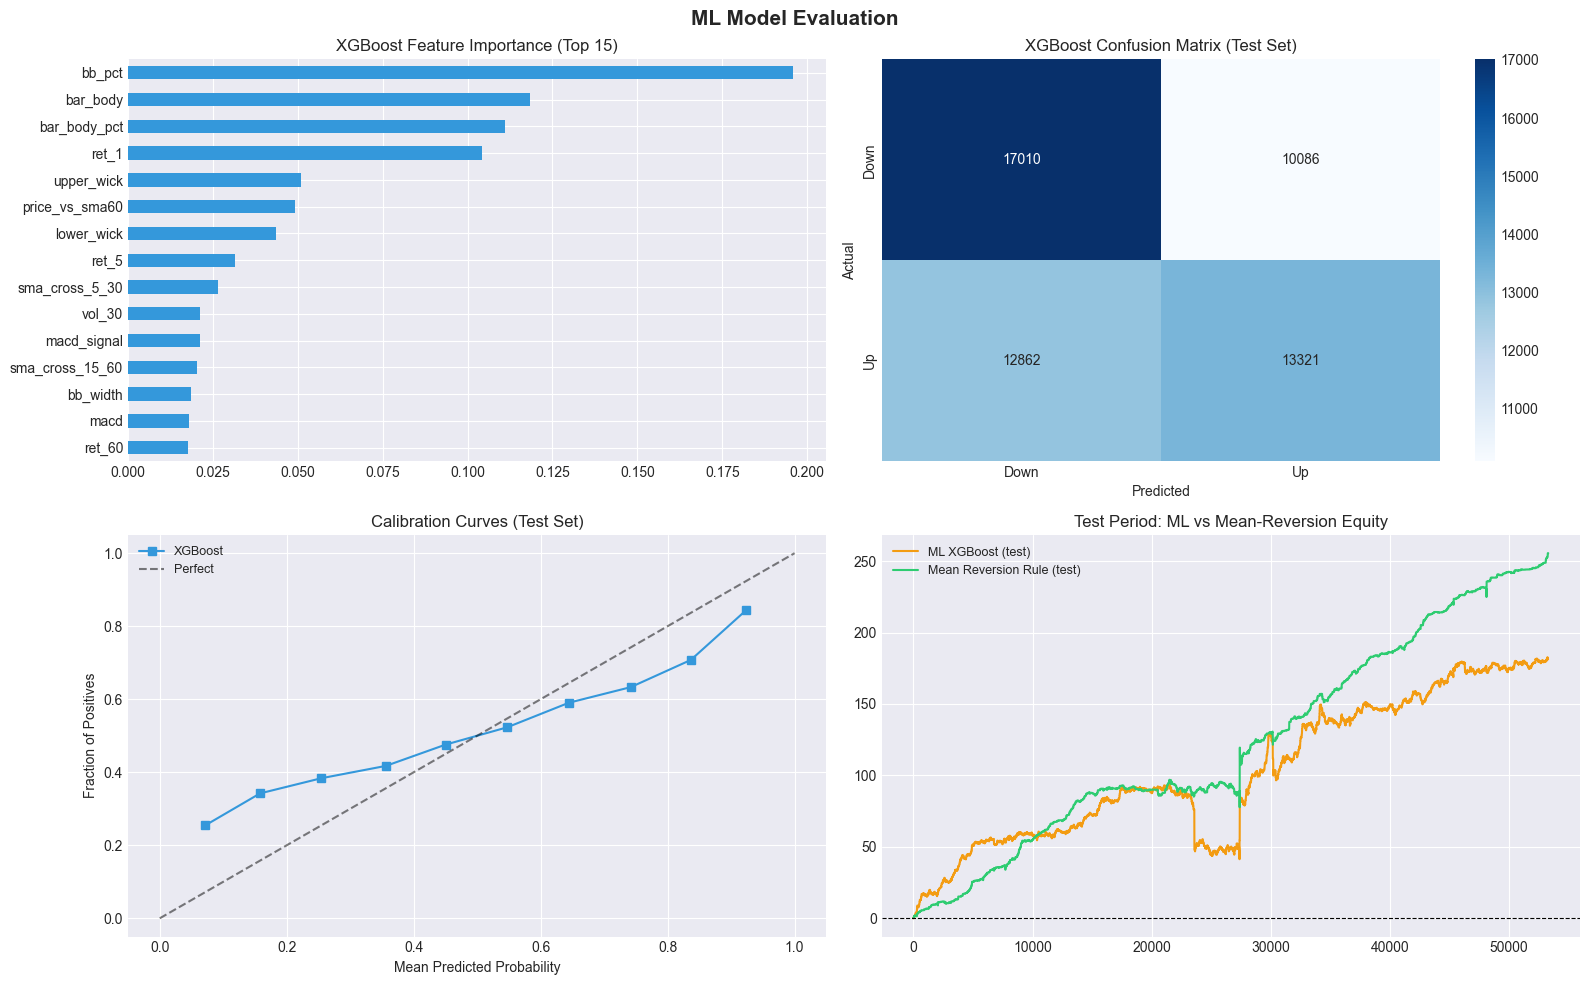

In [53]:
# Plot for best ML model (XGBoost in this case)
feature_importance(xgb_model, xgb_test_pred, xgb_test_prob, ec_mr_test, ec_ml_xgb, ml_model_name="XGBoost")


Top 10 Feature Importances (RF):
bb_pct            0.2328
bar_body_pct      0.1718
ret_1             0.1132
bar_body          0.1080
price_vs_sma60    0.0620
ret_5             0.0557
upper_wick        0.0334
lower_wick        0.0281
ret_15            0.0268
macd_hist         0.0187


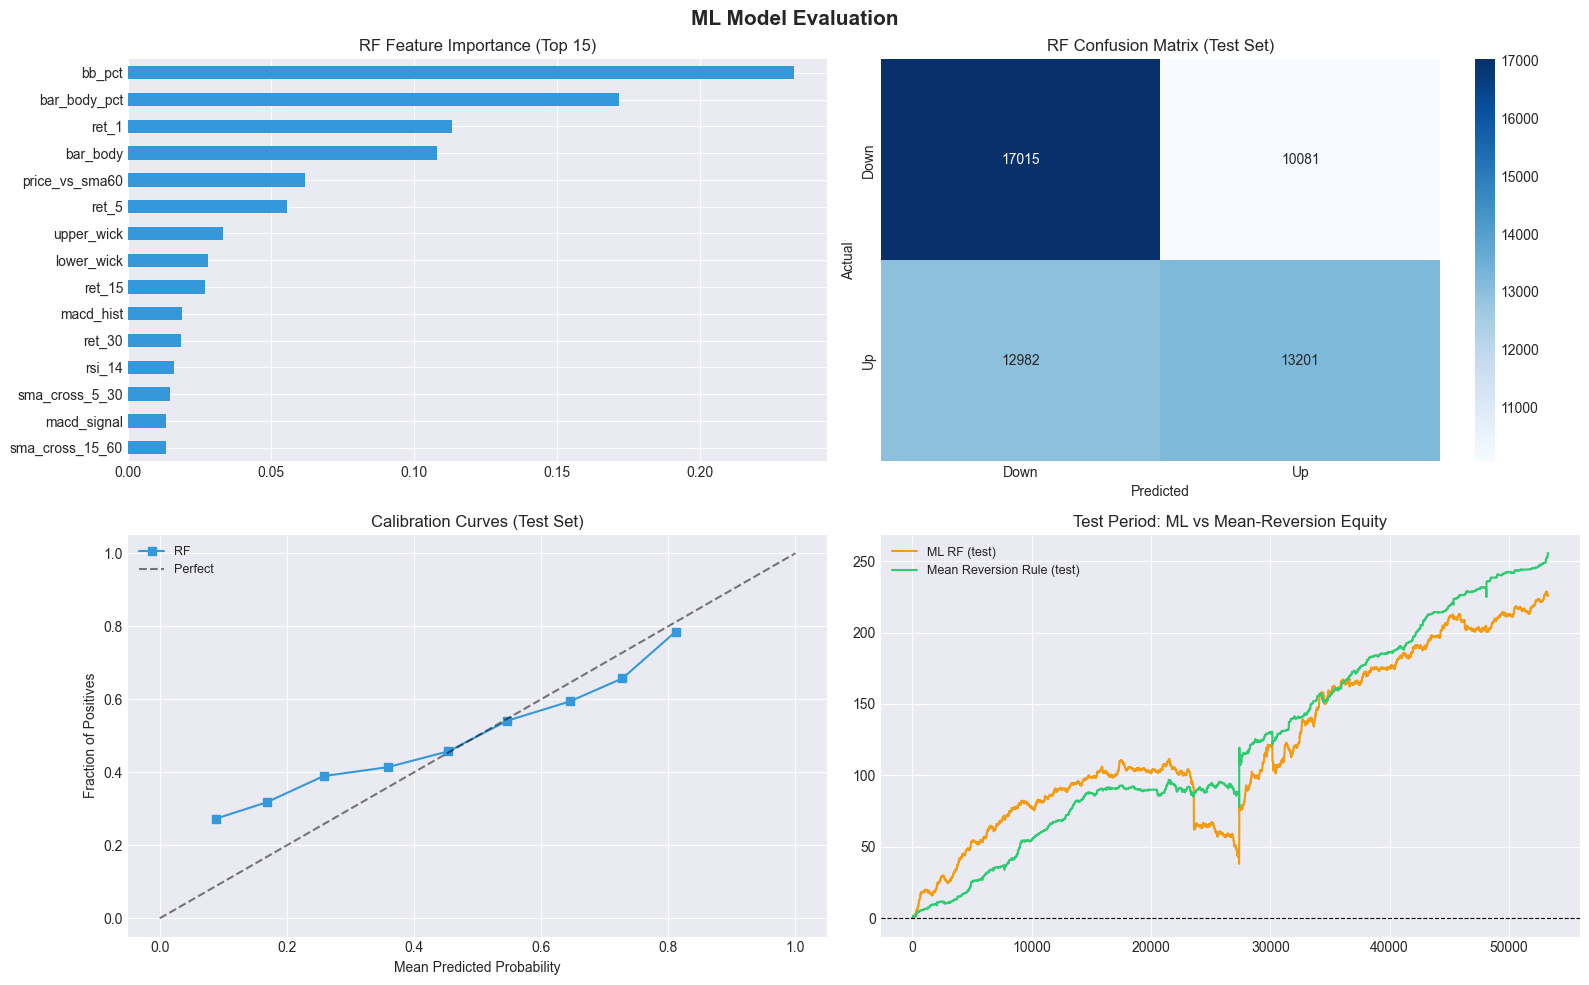

In [56]:
feature_importance(rf, rf_test_pred, rf_test_prob, ec_mr_test, ec_ml_rf, ml_model_name="RF")

In [58]:
# Summary table
print("\n" + "="*60)
print("STRATEGY COMPARISON SUMMARY")
print("="*60)
summary = pd.DataFrame({
    'Metric': ['Total PnL','Ann. PnL','Sharpe','Sortino','Max DD ($)','Win Rate','Profit Factor','N Trades'],
    'Trend v1': [
      rb_perf['total_return'], rb_perf['ann_return'], rb_perf['sharpe'],
      rb_perf['sortino'], rb_perf['max_dd'], rb_perf['win_rate'],
      rb_perf['profit_factor'], rb_perf['n_trades']
    ],
    'Trend v2': [
      rb_perf2['total_return'], rb_perf2['ann_return'], rb_perf2['sharpe'],
      rb_perf2['sortino'], rb_perf2['max_dd'], rb_perf2['win_rate'],
      rb_perf2['profit_factor'], rb_perf2['n_trades']
    ],
    'Mean-Rev (full)': [
      rb_perf_mr['total_return'], rb_perf_mr['ann_return'], rb_perf_mr['sharpe'],
      rb_perf_mr['sortino'], rb_perf_mr['max_dd'], rb_perf_mr['win_rate'],
      rb_perf_mr['profit_factor'], rb_perf_mr['n_trades']
    ],
    'ML LR (test)': [
      lr_ml_perf['total_return'], lr_ml_perf['ann_return'], lr_ml_perf['sharpe'],
      lr_ml_perf['sortino'], lr_ml_perf['max_dd'], lr_ml_perf['win_rate'],
      lr_ml_perf['profit_factor'], lr_ml_perf['n_trades']
    ],
    'ML RF (test)': [
      rf_ml_perf['total_return'], rf_ml_perf['ann_return'], rf_ml_perf['sharpe'],
      rf_ml_perf['sortino'], rf_ml_perf['max_dd'], rf_ml_perf['win_rate'],
      rf_ml_perf['profit_factor'], rf_ml_perf['n_trades']
    ],
    'ML LGBM (test)': [
      lgbm_ml_perf['total_return'], lgbm_ml_perf['ann_return'], lgbm_ml_perf['sharpe'],
      lgbm_ml_perf['sortino'], lgbm_ml_perf['max_dd'], lgbm_ml_perf['win_rate'],
      lgbm_ml_perf['profit_factor'], lgbm_ml_perf['n_trades']
    ],
    'ML XGB (test)': [
      xgb_ml_perf['total_return'], xgb_ml_perf['ann_return'], xgb_ml_perf['sharpe'],
      xgb_ml_perf['sortino'], xgb_ml_perf['max_dd'], xgb_ml_perf['win_rate'],
      xgb_ml_perf['profit_factor'], xgb_ml_perf['n_trades']
    ],
    'MR (test)': [
      mr_perf_test['total_return'], mr_perf_test['ann_return'], mr_perf_test['sharpe'],
      mr_perf_test['sortino'], mr_perf_test['max_dd'], mr_perf_test['win_rate'],
      mr_perf_test['profit_factor'], mr_perf_test['n_trades']
    ],
})
summary = summary.set_index('Metric')
print(summary.round(3).to_string())


STRATEGY COMPARISON SUMMARY
                Trend v1  Trend v2  Mean-Rev (full)  ML LR (test)  ML RF (test)  ML LGBM (test)  ML XGB (test)  MR (test)
Metric                                                                                                                   
Total PnL      -1398.187  -461.427          644.274       110.780       225.620             0.0        181.340    255.686
Ann. PnL       -1883.531  -621.599          867.917       754.530      1536.713             0.0       1235.119   1741.035
Sharpe           -29.619   -12.471            9.690         4.949        10.765             0.0          8.217     15.591
Sortino          -10.518    -2.722            1.851         1.910         3.260             0.0          2.697      2.840
Max DD ($)     -1398.987  -461.427          -93.129       -64.660       -73.590             0.0        -53.060    -19.236
Win Rate           0.390     0.223            0.627         0.552         0.571             0.0          0.549      0

Overall, the comparison shows a very clear separation between failing directional trend strategies, moderately performing machine learning models, and a strongly dominant mean-reversion strategy. The two trend variants (Trend v1 and v2) are decisively unprofitable, with large negative total and annualised PnL, extremely negative Sharpe ratios, and high drawdowns that effectively mirror the full loss of capital. This indicates that the underlying trend hypothesis is not aligned with the data generating process at this horizon, and the strategies are consistently extracting negative edge rather than noise.

In contrast, the machine learning models (Logistic Regression, Random Forest, XGBoost, and LightGBM) show mixed but generally positive performance, suggesting that there is some predictive structure in the features. Random Forest and XGBoost perform the best among the ML models, with respectable Sharpe ratios and positive profit factors, indicating that nonlinear interactions in the data are being captured to some extent. Logistic Regression is weaker but still positive, implying that a linear signal exists but is limited in strength. However, LightGBM producing zero results is a clear anomaly and points to a likely implementation or pipeline issue rather than a true model outcome.

The mean-reversion strategy stands out as the strongest performer across nearly all metrics, with the highest Sharpe and Sortino ratios, the best profit factor, and the lowest drawdown. Its win rate is also the highest, suggesting a highly consistent edge driven by frequent small gains with controlled downside risk. However, the magnitude of the Sharpe ratio is unusually high in an annualised context, which raises the possibility that the strategy may be benefiting from overly favourable backtest assumptions such as low transaction costs, absence of slippage, or potential feature leakage. While the raw results are very strong, they should be interpreted cautiously until the robustness of the backtest framework is fully validated.

Finally, across all strategies, there is a noticeable inconsistency in performance dispersion and scale, particularly in the number of trades and volatility profiles. This suggests that the strategies are not being compared under perfectly normalised risk conditions, which can distort relative performance conclusions. In summary, the results indicate that mean reversion is the dominant signal in the current feature set, machine learning models provide incremental but limited improvement, and trend-following is fundamentally misaligned with the data. However, before drawing firm conclusions about edge magnitude, the backtest assumptions and data pipeline should be carefully audited for leakage, cost modelling, and consistency in exposure scaling.